## 该图在散点图的基础上，通过椭圆描述了数据分布特征，使表达更加直观。可用于绘制主成分分析图（PCA）或其他具有群体分布特征的数据~


In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from matplotlib.patches import Ellipse
from matplotlib.colors import to_rgba

In [5]:
"""加载样式文件（如果存在），并设置中文字体支持"""
# 设置样式
try:
    plt.style.use("scatter.mplstyle")
except:
    pass
# 使用Nature常用的无衬线字体，Ubuntu系统兼容
plt.rcParams["font.sans-serif"] = ["Liberation Sans", "Arial", "Helvetica", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

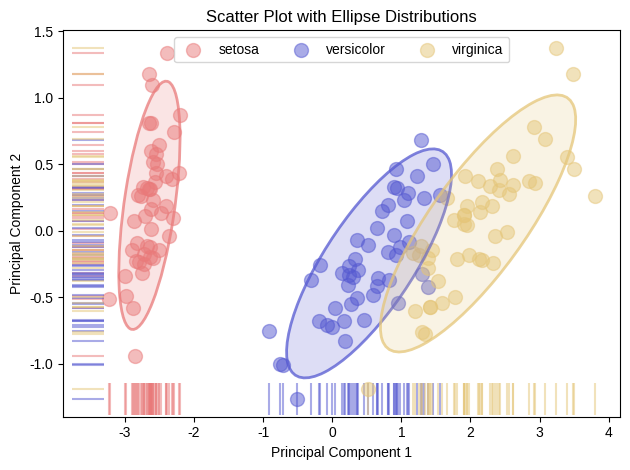

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from matplotlib.patches import Ellipse
from matplotlib.colors import to_rgba

### Configuration Items
# Whether to read a custom dataset
read_custom_data = False  
# Data path (used when custom data is enabled)
data_path = "data.csv"  

# Define plotting colors: color for scatter points and distribution ellipses of each category
colors = {
    "setosa": "#e97a7a", 
    "versicolor": "#5559d1", 
    "virginica": "#e5c679"
}

# Function to draw distribution ellipses
def draw_ellipse(sub_df, ax, n_std=2.0, color="black"):
    cov = np.cov(sub_df["Principal Component 1"], sub_df["Principal Component 2"])
    mean = sub_df[["Principal Component 1", "Principal Component 2"]].mean().values

    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]

    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(vals)

    ellip = Ellipse(
        xy=mean, 
        width=width, 
        height=height, 
        angle=theta,
        edgecolor=to_rgba(color, alpha=0.75),
        facecolor=to_rgba(color, alpha=0.2),
        linewidth=2,
    )
    ax.add_patch(ellip)

# Read or create data
if read_custom_data:
    # Read data from CSV
    df = pd.read_csv(data_path)
else:
    # Load the Iris dataset
    iris = load_iris()
    X = iris.data
    y = iris.target
    feature_names = iris.feature_names
    target_names = iris.target_names
    
    # PCA dimensionality reduction (retain 2 principal components)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    
    # Construct DataFrame
    df = pd.DataFrame({
        "Principal Component 1": X_pca[:, 0], 
        "Principal Component 2": X_pca[:, 1], 
        "Category": [target_names[i] for i in y],
    })

# Plotting: Create the canvas
fig, ax = plt.subplots()

# Calculate the minimum values of the horizontal and vertical axes for drawing projection markers
x_min = df["Principal Component 1"].min() - 0.3  # Fine-tune position
y_min = df["Principal Component 2"].min()

# Draw scatter points (main scatter points + horizontal axis projections + vertical axis projections)
for category in df["Category"].unique():
    subset = df[df["Category"] == category]
    c = colors[category]
    
    # Main scatter points
    ax.scatter(
        subset["Principal Component 1"], subset["Principal Component 2"],
        label=category, color=c, s=100, alpha=0.5
    )
    
    # Vertical axis projections (horizontal line markers at y=y_min)
    ax.scatter(
        subset["Principal Component 1"], [y_min] * len(subset["Principal Component 1"]),
        marker="|", c=c, alpha=0.5, s=500,
    )
    
    # Horizontal axis projections (vertical line markers at x=x_min)
    ax.scatter(
        [x_min] * len(subset["Principal Component 1"]), subset["Principal Component 2"],
        marker="_", c=c, alpha=0.5, s=500,
    )

# Draw distribution ellipses for each category
for category in df["Category"].unique():
    subset = df[df["Category"] == category]
    draw_ellipse(subset, ax, color=colors[category])

# Set title, axes, and legend
ax.set_title("Scatter Plot with Ellipse Distributions")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.legend(ncols=3)

# Optimize layout and display
plt.tight_layout()
# plt.savefig('./Fig.pdf', dpi=300, bbox_inches='tight')    
plt.show()